In [1]:
import tensorflow as tf 
from tensorflow import keras

import pandas as pd 
import numpy as np

In [2]:
fashion_mnist= keras.datasets.fashion_mnist
(x_train_full,y_train_full),(x_test,y_test)= fashion_mnist.load_data()
x_train_full.shape


(60000, 28, 28)

In [3]:
x_train_full.dtype

dtype('uint8')

In [ ]:
x_valid, x_train = x_train_full[:5000] / 255.0, x_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
x_test = x_test / 255.0

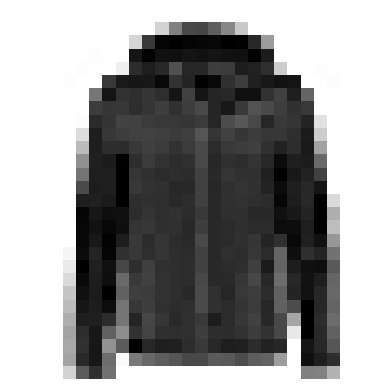

In [5]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap="binary")
plt.axis('off')
plt.show()

In [6]:
y_train

array([4, 0, 7, ..., 3, 0, 5], dtype=uint8)

In [7]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [8]:
class_names[y_train[0]]

'Coat'

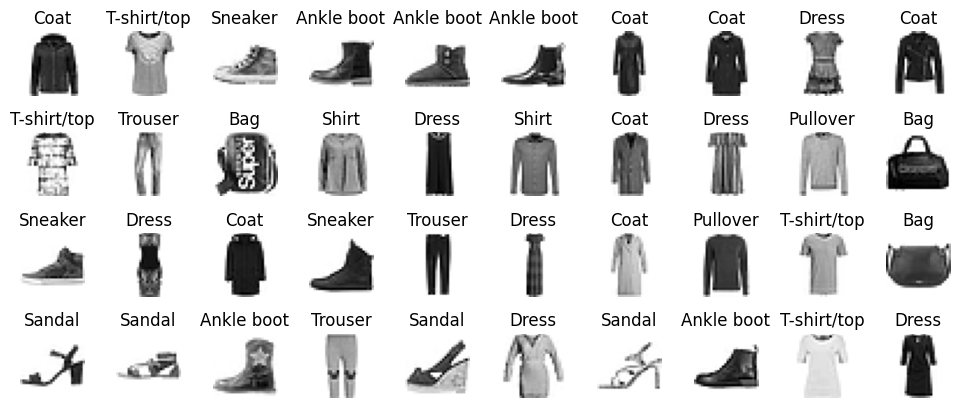

In [9]:
n_rows=4
n_cols=10
plt.figure(figsize=(n_cols*1.2,n_rows*1.2))

for rows in range(n_rows):
    for cols in range(n_cols):
        index= rows*n_cols+cols
        plt.subplot(n_rows,n_cols,index+1)
        plt.imshow(x_train[index],cmap="binary")
        plt.axis('off')
        plt.title(class_names[y_train[index]],fontsize=12)


plt.subplots_adjust(wspace=0.5,hspace=0.5)
plt.show()

In [10]:
tf.random.set_seed(42)
model=tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(input_shape=[28,28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300,activation="relu"))
model.add(tf.keras.layers.Dense(100,activation="relu"))
model.add(tf.keras.layers.Dense(10,activation="softmax"))

c:\Users\Aaditya Saini\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [18]:
hidden1=model.layers[1]
hidden1.name

'dense'

In [19]:
weights, biases = hidden1.get_weights()
weights

array([[ 0.04229925,  0.0670711 ,  0.04382326, ..., -0.0032425 ,
        -0.03462672, -0.01588216],
       [-0.01033168, -0.00838339, -0.02583572, ..., -0.0656547 ,
         0.01446784,  0.05835411],
       [-0.00683216, -0.03322316,  0.05968454, ...,  0.02931835,
        -0.048887  , -0.00737398],
       ...,
       [ 0.04404335,  0.01453798, -0.07072921, ..., -0.04882571,
        -0.01693546,  0.00582923],
       [-0.05897414, -0.00220922,  0.06312923, ..., -0.04710567,
         0.0216217 ,  0.00791489],
       [-0.01879287,  0.07383032,  0.04105467, ...,  0.01073009,
         0.03931496,  0.01485332]], dtype=float32)

In [20]:
weights.shape


(784, 300)

In [21]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [27]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [28]:
tf.keras.utils.to_categorical([0,5,1,0],num_classes=10
)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [29]:
np.argmax(
    [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
     [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
     [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
    axis=1
)

array([0, 5, 1, 0], dtype=int64)

In [49]:
history=model.fit(x_train,y_train,epochs=50,validation_data=(x_valid,y_valid))

Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9206 - loss: 0.2239 - val_accuracy: 0.8878 - val_loss: 0.3015
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9220 - loss: 0.2203 - val_accuracy: 0.8886 - val_loss: 0.3017
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9239 - loss: 0.2168 - val_accuracy: 0.8882 - val_loss: 0.3020
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9246 - loss: 0.2132 - val_accuracy: 0.8880 - val_loss: 0.3020
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9259 - loss: 0.2097 - val_accuracy: 0.8888 - val_loss: 0.3017
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9270 - loss: 0.2064 - val_accuracy: 0.8888 - val_loss: 0.3022
Epoch 7/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9286 - loss: 0.2028 - val_accuracy: 0.8902 - val_loss: 0.3009
Epoch 8/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9301 - loss: 0.1995 - 

In [50]:
history.params

{'verbose': 'auto', 'epochs': 50, 'steps': 1719}

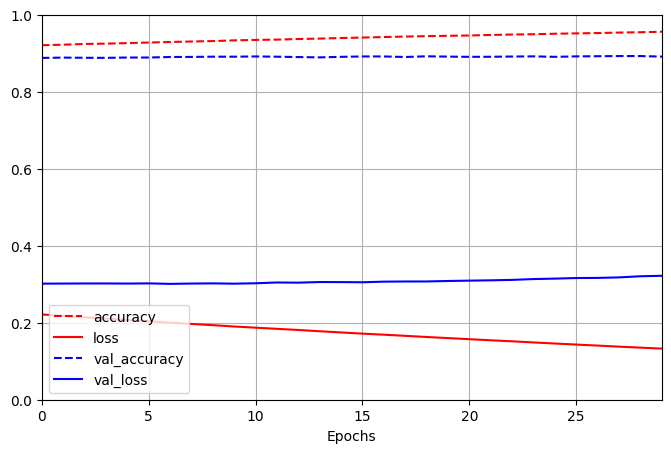

In [51]:
pd.DataFrame(history.history).plot(figsize=(8,5),grid=True, xlim=(0,29),ylim=(0,1),xlabel="Epochs",style=["r--","r-","b--","b-"])
plt.legend(loc="lower left")
plt.show()


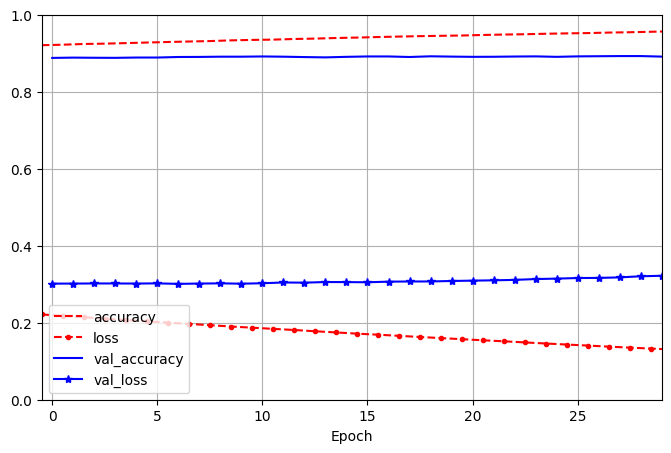

In [52]:
plt.figure(figsize=(8, 5))
for key, style in zip(history.history, ["r--", "r--.", "b-", "b-*"]):
    epochs = np.array(history.epoch) + (0 if key.startswith("val_") else -0.5)
    plt.plot(epochs, history.history[key], style, label=key)
plt.xlabel("Epoch")
plt.axis([-0.5, 29, 0., 1])
plt.legend(loc="lower left")
plt.grid()
plt.show()

In [44]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy: 0.8395 - loss: 68.6922


[71.31256103515625, 0.8367999792098999]

In [53]:
x_new = x_test[:3]
y_proba = model.predict(x_new)
y_proba.round(2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [54]:
y_pred=y_proba.argmax(axis=-1)
y_pred

array([9, 2, 1], dtype=int64)

In [55]:
y_new = y_test[:3]
y_new


array([9, 2, 1], dtype=uint8)

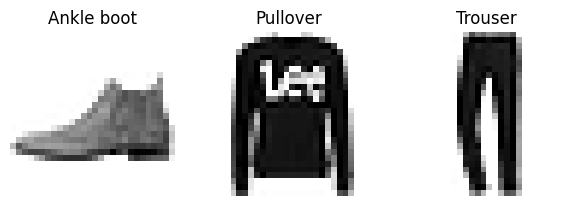

In [56]:
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(x_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

In [57]:
print(f"Training loss:    {history.history['loss'][-1]:.4f}")
print(f"Validation loss:  {history.history['val_loss'][-1]:.4f}")
print(f"Training acc:     {history.history['accuracy'][-1]:.4f}")
print(f"Validation acc:   {history.history['val_accuracy'][-1]:.4f}")

Training loss:    0.0880
Validation loss:  0.3636
Training acc:     0.9734
Validation acc:   0.8912
